## Introduction

In this project I focus on analysing sales and invnetory data to identify tresnts,  evaluate product performance, and support inventoryu management. I will use a standard sales sample data from Kaggle.


Dataset source: https://www.kaggle.com/datasets/vinothkannaece/sales-dataset?resource=download


In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import inventorize3 as inv

# Load the dataset
df = pd.read_csv('sales_data.csv')

In [132]:
# Display the first few rows of the dataset
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [133]:
# display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


## Data Preparation & Cleaning

In this section I ensure the integrity of the dataset by checking for null values, duplicated values, and data anomalies. 

In [134]:
# check for null values
print("Null values", df.isnull().sum().sum())

Null values 0


In [135]:
# check for data anomaly
(df['Quantity_Sold'] < 0).sum()


np.int64(0)

In [136]:
# check for negative values in unit cost
(df['Unit_Cost'] < 0).sum()

np.int64(0)

In [137]:
# check for negative values in unit price
(df['Unit_Price'] < 0).sum()

np.int64(0)

In [138]:
# check for duplicated value
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

In this section I will explore the dataset through visualisations and analysis to identify patterns, trends, and key insights.

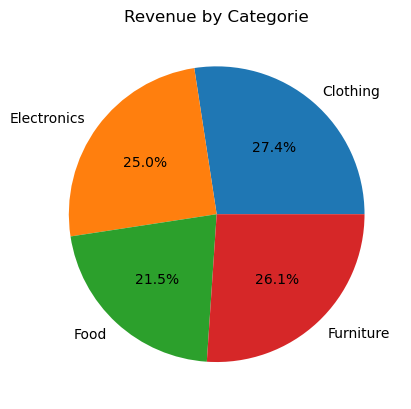

In [173]:
df['Revenue'] = df['Quantity_Sold'] * df['Unit_Price']

categorie_revenue = df.groupby('Product_Category')['Revenue'].sum()

fix, ax = plt.subplots()
ax.pie(categorie_revenue.values, labels=categorie_revenue.index, autopct='%1.1f%%')
plt.title("Revenue by Categorie")

plt.savefig('images/revenue_by_categorie.png',
            bbox_inches='tight')

plt.show()

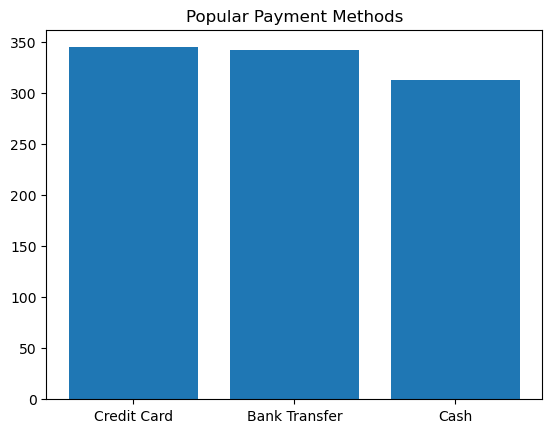

In [174]:
most_popular_payment_methods = df['Payment_Method'].value_counts()

plt.bar(most_popular_payment_methods.index, most_popular_payment_methods.values)
plt.title("Popular Payment Methods")

plt.savefig('images/payment_methods.png',
            bbox_inches='tight')
plt.show()


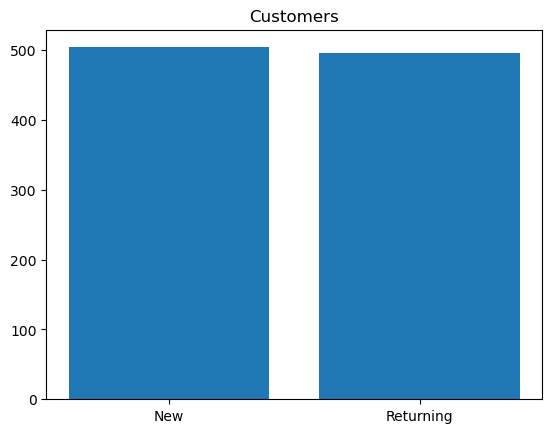

In [175]:
customer_types = df['Customer_Type'].value_counts()

plt.bar(customer_types.index, customer_types.values)
plt.title("Customers")
plt.savefig('images/customer_types.png',
            bbox_inches='tight')
plt.show()

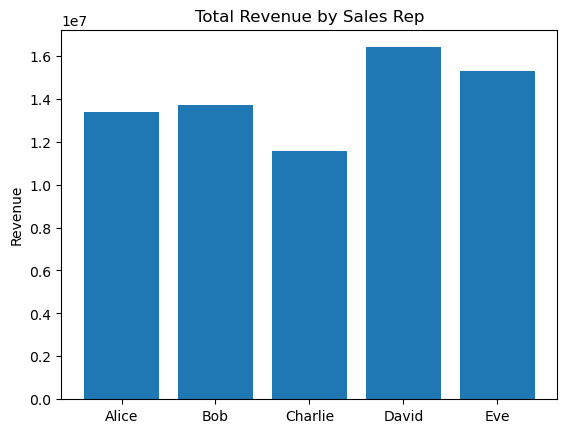

In [176]:
sales_rep_by_quantity_sold = df.groupby('Sales_Rep')['Quantity_Sold'].sum()

# number_of_sales_per_rep = df['Sales_Rep'].value_counts()

total_revenue_by_rep = df.groupby('Sales_Rep').agg({
    'Quantity_Sold': 'sum',
    'Revenue': 'sum'
})

plt.bar(total_revenue_by_rep.index, total_revenue_by_rep['Revenue'])
plt.title('Total Revenue by Sales Rep')
plt.ylabel('Revenue')
plt.savefig('images/total_revenue_by_rep.png',
            bbox_inches='tight')
plt.show()

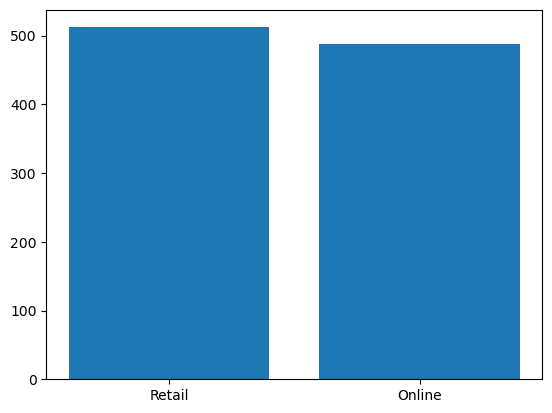

In [177]:
sales_channels = df['Sales_Channel'].value_counts()

plt.bar(sales_channels.index, sales_channels.values)
plt.savefig('images/sales_channels.png',
            bbox_inches='tight')
plt.show()

## ABC_XYZ Analysis

A = most profitable items
B = intermediate products
C = least valuable

XYZ classes measure demand variation over a given period

X = products with stable demand
Y = moderatly stable
Z = highly fluctuating demand


In [144]:
abc_xyz_data = df[['Product_ID', 'Sale_Date', 'Quantity_Sold', 'Unit_Cost']]

abc_xyz_data

,Product_ID,Sale_Date,Quantity_Sold,Unit_Cost
0,1052,2023-02-03,18,152.75
1,1093,2023-04-21,17,3816.39
2,1015,2023-09-21,30,261.56
3,1072,2023-08-24,39,4330.03
4,1061,2023-03-24,13,637.37
...,...,...,...,...
995,1010,2023-04-15,4,4943.03
996,1067,2023-09-07,37,1754.32
997,1018,2023-04-27,17,355.72
998,1100,2023-12-20,39,3685.03


In [145]:
# convert Sale date to monthly sales

abc_xyz_data['Sale_Date'] = pd.to_datetime(abc_xyz_data['Sale_Date'])
abc_xyz_data = abc_xyz_data[(abc_xyz_data['Sale_Date'] >= '2023-01-01') & (df['Sale_Date'] <'2023-12-30')]


abc_xyz_data['Month'] = pd.to_datetime(abc_xyz_data['Sale_Date']).dt.month

abc_xyz_data = abc_xyz_data.drop(columns=['Sale_Date']).sort_values('Month')

In [146]:
abc_data = abc_xyz_data.copy()

In [147]:
abc_data['Consumption_Value'] = abc_data['Quantity_Sold'] * abc_data['Unit_Cost']

In [148]:
abc_data = (abc_data.groupby('Product_ID').agg(
        Annual_Units_Sold=('Quantity_Sold', 'sum'),
        Annual_Consumption_Value=('Consumption_Value', 'sum')
    ).reset_index()
)

In [149]:
total_acv = abc_data['Annual_Consumption_Value'].sum()

total_acv

np.float64(63046394.75)

In [150]:
total_year_units_sold = abc_data['Annual_Units_Sold'].sum()

total_year_units_sold

np.int64(25027)

In [151]:
abc_data['Item_Percentage'] = abc_data['Annual_Units_Sold'] / total_year_units_sold * 100

In [152]:
abc_data['Consumption_percentage'] = abc_data['Annual_Consumption_Value'] / total_acv * 100

In [153]:
abc_data = abc_data.sort_values(
    'Annual_Consumption_Value',
    ascending=False
)

In [154]:
abc_data['Cumulative_Percentage'] = abc_data['Consumption_percentage'].cumsum()

In [155]:
def ABC(Cumulative_Percentage):
    if Cumulative_Percentage <= 80:
        return 'A'
    elif Cumulative_Percentage <= 95:
        return 'B'
    else:
        return 'C'

In [156]:
abc_data[['Product_ID', 'Cumulative_Percentage']].sort_values('Cumulative_Percentage')

,Product_ID,Cumulative_Percentage
91,1092,2.506298
89,1090,4.776722
98,1099,7.034868
88,1089,9.155348
53,1054,11.029324
...,...,...
40,1041,98.641681
17,1018,99.037217
10,1011,99.397365
30,1031,99.724274


In [157]:
abc_data['ABC'] = abc_data['Cumulative_Percentage'].apply(ABC)

In [158]:
abc_data['ABC'].value_counts()

ABC
A    64
B    23
C    13
Name: count, dtype: int64

# XYZ


In [159]:
xyz_data = (abc_xyz_data.groupby(['Product_ID', 'Month'])['Quantity_Sold'].sum().reset_index())

xyz_data

,Product_ID,Month,Quantity_Sold
0,1001,2,27
1,1001,4,27
2,1001,5,97
3,1001,8,44
4,1001,9,39
...,...,...,...
662,1100,5,29
663,1100,8,43
664,1100,9,36
665,1100,11,15


In [160]:
xyz_data['Average_Demand'] = (xyz_data.groupby('Product_ID')['Quantity_Sold'].transform('mean'))

In [161]:
xyz_data['STD_Demand'] = (xyz_data.groupby('Product_ID')['Quantity_Sold'].transform('std'))

In [162]:
xyz_data['CV'] = xyz_data['STD_Demand'] / xyz_data['Average_Demand']

In [163]:
def XYZ(CV):
    if CV < 0.25:
        return 'X'
    elif CV <= 0.5:
        return 'Y'
    else:
        return 'Z'


In [164]:
xyz_data['XYZ'] = xyz_data["CV"].apply(XYZ)

xyz_data

,Product_ID,Month,Quantity_Sold,Average_Demand,STD_Demand,CV,XYZ
0,1001,2,27,46.750000,22.043788,0.471525,Y
1,1001,4,27,46.750000,22.043788,0.471525,Y
2,1001,5,97,46.750000,22.043788,0.471525,Y
3,1001,8,44,46.750000,22.043788,0.471525,Y
4,1001,9,39,46.750000,22.043788,0.471525,Y
...,...,...,...,...,...,...,...
662,1100,5,29,39.833333,19.333046,0.485348,Y
663,1100,8,43,39.833333,19.333046,0.485348,Y
664,1100,9,36,39.833333,19.333046,0.485348,Y
665,1100,11,15,39.833333,19.333046,0.485348,Y


In [165]:
xyz_data['XYZ'].value_counts()

XYZ
Z    518
Y    140
X      9
Name: count, dtype: int64

ABC Analysis`

In [166]:
xyz_summary = xyz_data[['Product_ID', 'Average_Demand', 'STD_Demand', 'CV', 'XYZ']].drop_duplicates()

xyz_summary

,Product_ID,Average_Demand,STD_Demand,CV,XYZ
0,1001,46.750000,22.043788,0.471525,Y
8,1002,34.222222,25.621172,0.748671,Z
17,1003,29.714286,21.203100,0.713566,Z
24,1004,32.857143,31.088200,0.946163,Z
31,1005,31.571429,22.648452,0.717372,Z
...,...,...,...,...,...
629,1096,28.416667,11.341463,0.399113,Y
641,1097,43.000000,25.396850,0.590624,Z
646,1098,19.166667,9.887703,0.515880,Z
652,1099,52.555556,30.463548,0.579645,Z


In [167]:
abc_xyz = abc_data.merge(
    xyz_summary,
    on='Product_ID',
    how='inner'
)

abc_xyz

,Product_ID,Annual_Units_Sold,Annual_Consumption_Value,Item_Percentage,Consumption_percentage,Cumulative_Percentage,ABC,Average_Demand,STD_Demand,CV,XYZ
0,1092,548,1580130.40,2.189635,2.506298,2.506298,A,60.888889,26.131611,0.429169,Y
1,1090,544,1431420.35,2.173652,2.270424,4.776722,A,54.400000,27.439631,0.504405,Z
2,1099,473,1423679.67,1.889959,2.258146,7.034868,A,52.555556,30.463548,0.579645,Z
3,1089,390,1336886.31,1.558317,2.120480,9.155348,A,43.333333,34.590461,0.798241,Z
4,1054,348,1181474.37,1.390498,1.873976,11.029324,A,49.714286,17.518697,0.352388,Y
...,...,...,...,...,...,...,...,...,...,...,...
95,1041,151,249635.40,0.603348,0.395955,98.641681,C,37.750000,5.560276,0.147292,X
96,1018,136,249371.47,0.543413,0.395536,99.037217,C,27.200000,17.569861,0.645951,Z
97,1011,75,227060.21,0.299676,0.360148,99.397365,C,18.750000,15.217862,0.811619,Z
98,1031,64,206104.26,0.255724,0.326909,99.724274,C,21.333333,11.015141,0.516335,Z


In [168]:
abc_xyz['ABC_XYZ'] = abc_xyz['ABC'] + abc_xyz['XYZ']

### ABC_XYZ Matrix

Use this matrix and the column ABC_XYZ to determine stocking policies per Product_ID

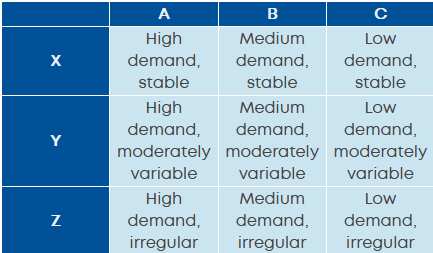

Source: https://www.mecalux.com/blog/abc-xyz

In [169]:
abc_xyz[['Product_ID', 'ABC', 'XYZ', 'ABC_XYZ']]

,Product_ID,ABC,XYZ,ABC_XYZ
0,1092,A,Y,AY
1,1090,A,Z,AZ
2,1099,A,Z,AZ
3,1089,A,Z,AZ
4,1054,A,Y,AY
...,...,...,...,...
95,1041,C,X,CX
96,1018,C,Z,CZ
97,1011,C,Z,CZ
98,1031,C,Z,CZ


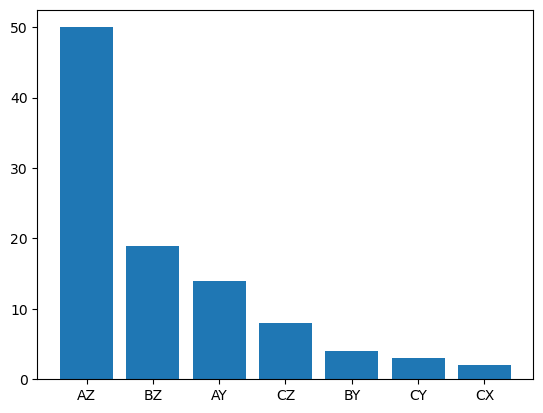

In [178]:
abc_xyz_counts = abc_xyz['ABC_XYZ'].value_counts()


plt.bar(abc_xyz_counts.index, abc_xyz_counts.values)
plt.savefig('images/abc_xyz_distribution.png',
            bbox_inches='tight')
plt.show()

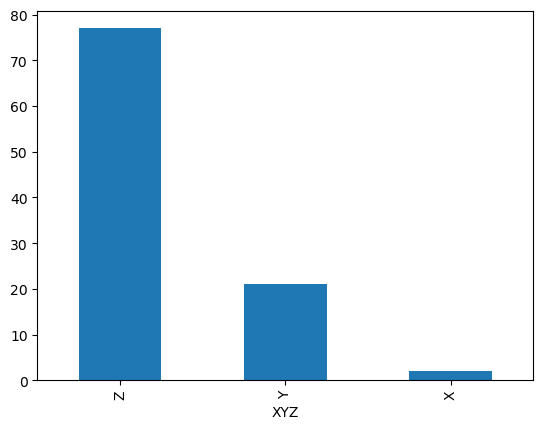

In [179]:
abc_xyz['XYZ'].value_counts().plot(kind='bar')
plt.savefig('images/xyz_distribution.png',
            bbox_inches='tight')
plt.show()

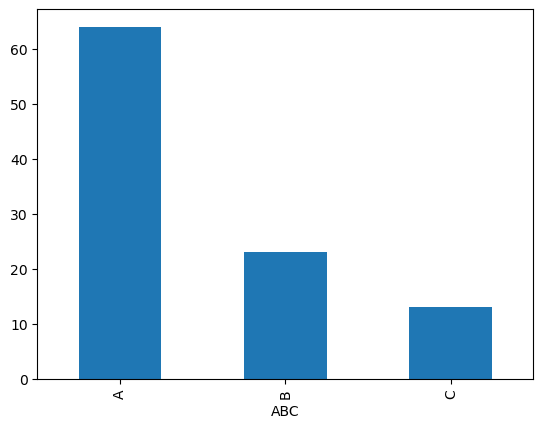

In [180]:
abc_xyz['ABC'].value_counts().plot(kind='bar')
plt.savefig('images/abc_distribution.png',
            bbox_inches='tight')
plt.show()

# Recommendations

1. A Class products generated over 60% of total revenue
2. Most Products fall into the Z category indicating highly fluctuating demand.
3. AZ was the largest ABC-XYZ segment, suggesting that many high-value products have irregular demand patterns.
4. Only a small number of products were classified as X, indicating stable demand.
